<a href="https://www.kaggle.com/code/sirinja/fighting-maternal-risk?scriptVersionId=258109743" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/mlolympiadbd2025/sample_submission.csv
/kaggle/input/mlolympiadbd2025/train.csv
/kaggle/input/mlolympiadbd2025/metaData.csv
/kaggle/input/mlolympiadbd2025/test.csv


In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
train = pd.read_csv('/kaggle/input/mlolympiadbd2025/train.csv')
test = pd.read_csv('/kaggle/input/mlolympiadbd2025/test.csv')

In [4]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 811 entries, 0 to 810
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             811 non-null    int64  
 1   Age            811 non-null    int64  
 2   SystolicBP     811 non-null    int64  
 3   DiastolicBP    811 non-null    int64  
 4   Blood glucose  811 non-null    float64
 5   BodyTemp       811 non-null    float64
 6   HeartRate      811 non-null    int64  
 7   RiskLevel      811 non-null    int64  
 8   Usage          811 non-null    object 
dtypes: float64(2), int64(6), object(1)
memory usage: 57.2+ KB


In [5]:
train.head(5)

,Id,Age,SystolicBP,DiastolicBP,Blood glucose,BodyTemp,HeartRate,RiskLevel,Usage
0,617,31,120,60,6.1,98.0,76,0,Train
1,774,23,120,90,7.8,98.0,60,1,Train
2,610,13,90,65,7.5,101.0,80,2,Train
3,525,42,120,80,7.5,98.0,70,0,Train
4,70,26,85,60,6.0,101.0,86,1,Train


In [6]:
train['RiskLevel'].unique()

array([0, 1, 2])

In [7]:
train['RiskLevel'].value_counts('p')*100

RiskLevel
0    40.073983
1    33.168927
2    26.757090
Name: proportion, dtype: float64

In [8]:
train.describe()

,Id,Age,SystolicBP,DiastolicBP,Blood glucose,BodyTemp,HeartRate,RiskLevel
count,811.000000,811.000000,811.000000,811.000000,811.000000,811.000000,811.000000,811.000000
mean,499.118372,29.912454,113.104809,76.290999,8.655758,98.663379,74.115906,0.866831
std,291.507683,13.505316,18.435744,13.798968,3.204997,1.372851,8.276928,0.807081
min,0.000000,10.000000,70.000000,49.000000,6.000000,98.000000,7.000000,0.000000
25%,251.000000,19.000000,100.000000,65.000000,6.900000,98.000000,70.000000,0.000000
50%,499.000000,26.000000,120.000000,80.000000,7.500000,98.000000,76.000000,1.000000
75%,745.500000,38.000000,120.000000,90.000000,8.000000,98.000000,80.000000,2.000000
max,1012.000000,70.000000,160.000000,100.000000,19.000000,103.000000,90.000000,2.000000


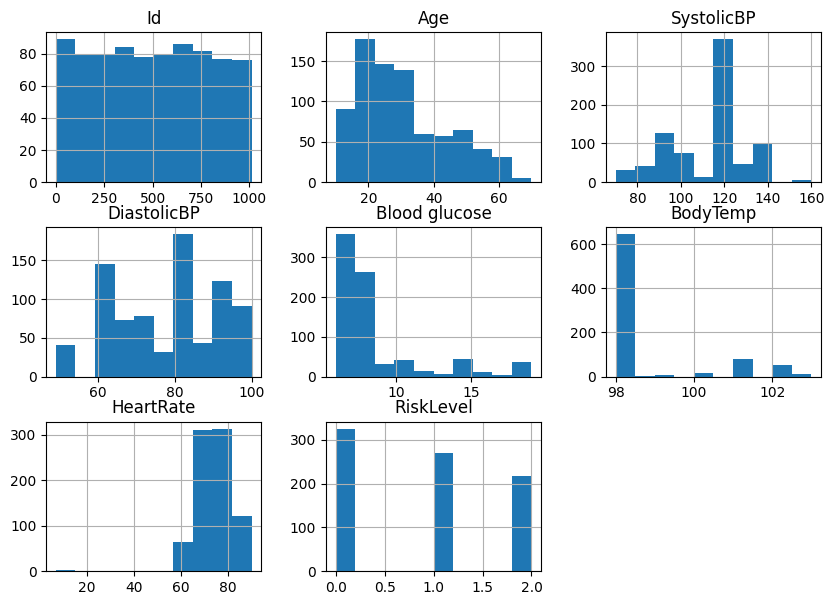

In [9]:
import matplotlib.pyplot as plt
train.hist(figsize=(10,7))
plt.show()

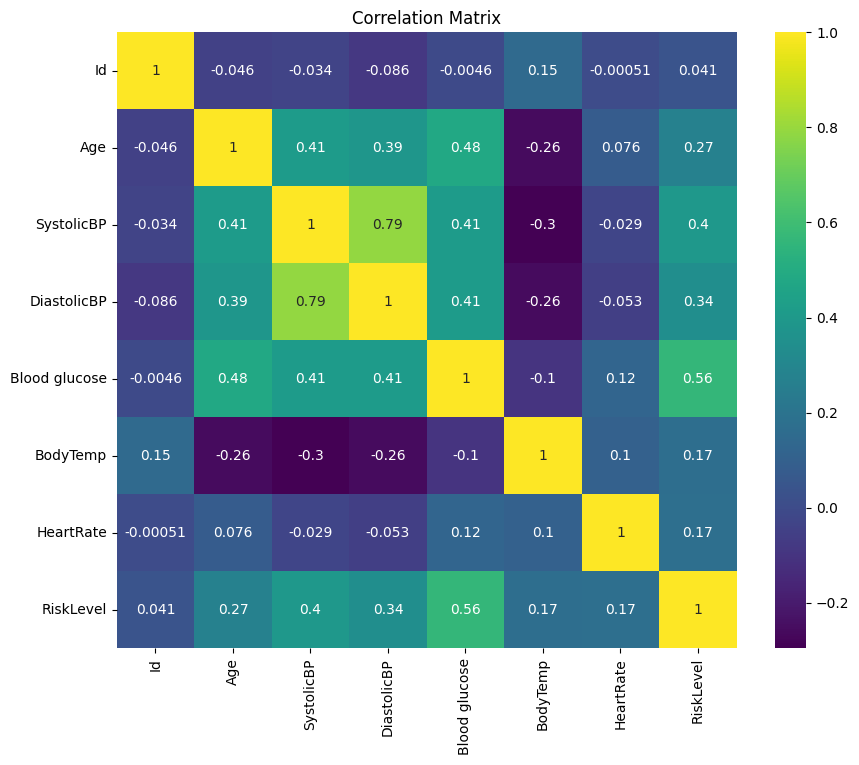

In [10]:
import seaborn as sns

# Generate a correlation matrix for all numerical columns in the DataFrame
corr_matrix = train.drop('Usage',axis=1).corr()

# Create a heatmap using seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='viridis')

# Set the title of the plot
plt.title('Correlation Matrix')

# Display the plot
plt.show()

In [11]:
# split data into features and target
X = train.drop(['Id','RiskLevel','Usage'], axis=1)
y = train['RiskLevel']

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,random_state=10, stratify=y)

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

# train random forest model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
# Calculate the accuracy of the classifier
scores = cross_val_score(rf, X, y, cv=5, scoring='accuracy')

#fit the model
rf.fit(X, y)

# get feature importance scores
importance = rf.feature_importances_

# create a DataFrame to store feature importance scores
feature_importance = pd.DataFrame({'feature': X.columns, 'importance': importance})

# sort the features by importance score in descending order
feature_importance = pd.Series(rf.feature_importances_, index=X.columns)

# print the feature importance scores
print(feature_importance.sort_values(ascending=False))

Blood glucose    0.365753
SystolicBP       0.181902
Age              0.162947
DiastolicBP      0.128656
HeartRate        0.099203
BodyTemp         0.061539
dtype: float64


In [14]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier


# Define the models
models = [
    ('LR', LogisticRegression()),
    ('DT', DecisionTreeClassifier()),
    ('RF', RandomForestClassifier()),
    ('SVM', SVC()),
    ('Naive', GaussianNB()),
    ('KNN',KNeighborsClassifier(n_neighbors=2))
]

# Evaluate each model using cross-validation
results = []
names = []
for name, model in models:
    cv_results = cross_val_score(model, X, y, cv=10, scoring='accuracy')
    results.append(cv_results)
    names.append(name)
    
    print(f"{name}: Mean accuracy = {round(cv_results.mean(),3)}, Standard deviation = {round(cv_results.std(),3)}")   

LR: Mean accuracy = 0.582, Standard deviation = 0.025
DT: Mean accuracy = 0.815, Standard deviation = 0.055
RF: Mean accuracy = 0.83, Standard deviation = 0.032
SVM: Mean accuracy = 0.591, Standard deviation = 0.044
Naive: Mean accuracy = 0.602, Standard deviation = 0.06
KNN: Mean accuracy = 0.723, Standard deviation = 0.059


In [15]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

clf = make_pipeline(StandardScaler(), RandomForestClassifier())

In [16]:
from sklearn.metrics import accuracy_score

clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)
final_accuracy = accuracy_score(y_test, y_pred)
print('Final accuracy:', round(final_accuracy,3))

Final accuracy: 0.836


In [17]:
X_final = test.drop(['Id','Usage'],axis=1)

In [18]:
# pred = clf.predict(X_final)
# pred_df = pd.DataFrame({
#    "Id": test["Id"],
#    "RiskLevel": pd.Series(pred).map({
#        0: "Low Risk",
#        1: "Mid Risk",
#        2: "High Risk"
#    })
#})
## pred_df.to_csv('submission.csv',index=False)